In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler


# Loading of the dataset

In [38]:
df=pd.read_csv("/kaggle/input/datasets/ujjawalagarwal87/crop-rec/Crop_recommendation.csv")
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


# EDA- Exploratory Data Analysis

In [39]:
# Printing first five rows of the dataset
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [40]:
# Defining shape of the dataframe 
# Here, there are 2200 rows and 8 colunms in the dataframe 
df.shape

(2200, 8)

In [41]:
# Printing last five rows of the dataset
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [42]:
# Defining data types of each column
df.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

In [43]:
# Defining null values in each column
df.isna()

,N,P,K,temperature,humidity,ph,rainfall,label
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
2195,False,False,False,False,False,False,False,False
2196,False,False,False,False,False,False,False,False
2197,False,False,False,False,False,False,False,False
2198,False,False,False,False,False,False,False,False


In [44]:
# Sum of null values in each column 
df.isna().sum()


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [45]:
# Total count of non-null values in each column
df.isnull().count()

N              2200
P              2200
K              2200
temperature    2200
humidity       2200
ph             2200
rainfall       2200
label          2200
dtype: int64

In [46]:
# Defining duplicated values in each column
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2195    False
2196    False
2197    False
2198    False
2199    False
Length: 2200, dtype: bool

In [47]:
# Counting Duplicated values in each column 
df.duplicated().sum()

np.int64(0)

In [48]:
# Finding unique values in each column
df.nunique()

N               137
P               117
K                73
temperature    2200
humidity       2200
ph             2200
rainfall       2200
label            22
dtype: int64

In [49]:
# Finding the counts of each label
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [50]:
# describing the dataframe
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [51]:
# Information related to dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [52]:
# Defining mean group by label 
df.groupby("label").mean()

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779
banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980
blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151
chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977
coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646
coffee,101.20,28.74,29.94,25.540477,58.869846,6.790308,158.066295
cotton,117.77,46.24,19.56,23.988958,79.843474,6.912675,80.398043
grapes,23.18,132.53,200.11,23.849575,81.875228,6.025937,69.611829
jute,78.40,46.86,39.99,24.958376,79.639864,6.732778,174.792798


# Seperating Features and Labels 

In [53]:
# seperating labels
labels_df=df["label"]
labels_df

0         rice
1         rice
2         rice
3         rice
4         rice
         ...  
2195    coffee
2196    coffee
2197    coffee
2198    coffee
2199    coffee
Name: label, Length: 2200, dtype: object

In [54]:
features_df=df.drop(columns=["label"],axis=1)
features_df

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507
2196,99,15,27,27.417112,56.636362,6.086922,127.924610
2197,118,33,30,24.131797,67.225123,6.362608,173.322839
2198,117,32,34,26.272418,52.127394,6.758793,127.175293


# Feature Scaling

In [55]:
scalar=StandardScaler()
scalar_features=scalar.fit_transform(features_df)
scalar_features

array([[ 1.0687974 , -0.34455075, -0.1016875 , ...,  0.47266646,
         0.04330173,  1.8103605 ],
       [ 0.93332887,  0.14061552, -0.14118477, ...,  0.39705125,
         0.73487256,  2.24205791],
       [ 0.25598625,  0.04964684, -0.08193887, ...,  0.48695381,
         1.77151047,  2.92106603],
       ...,
       [ 1.82742114, -0.61745677, -0.35841972, ..., -0.19123516,
        -0.13812031,  1.27141766],
       [ 1.80032743, -0.64777967, -0.27942519, ..., -0.86951801,
         0.37390383,  0.43154519],
       [ 1.44810927, -1.07230015, -0.35841972, ..., -0.49802006,
         0.40109573,  0.68200518]])

In [56]:
# Converting scalar_features to dataframe
scaled_feature_df=pd.DataFrame(scalar_features,columns=features_df.columns,index=features_df.index)
scaled_feature_df

,N,P,K,temperature,humidity,ph,rainfall
0,1.068797,-0.344551,-0.101688,-0.935587,0.472666,0.043302,1.810361
1,0.933329,0.140616,-0.141185,-0.759646,0.397051,0.734873,2.242058
2,0.255986,0.049647,-0.081939,-0.515898,0.486954,1.771510,2.921066
3,0.635298,-0.556811,-0.160933,0.172807,0.389805,0.660308,2.537048
4,0.743673,-0.344551,-0.121436,-1.083647,0.454792,1.497868,2.898373
...,...,...,...,...,...,...,...
2195,1.529390,-0.587134,-0.318922,0.228814,-0.227709,0.401395,1.352437
2196,1.312641,-1.163269,-0.417666,0.355720,-0.666947,-0.494413,0.445183
2197,1.827421,-0.617457,-0.358420,-0.293218,-0.191235,-0.138120,1.271418
2198,1.800327,-0.647780,-0.279425,0.129612,-0.869518,0.373904,0.431545


# Train test split

In [57]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(scaled_feature_df,labels_df,test_size=0.2,random_state=42,stratify=labels_df)


In [58]:
print(X_train)

             N         P         K  temperature  humidity        ph  rainfall
1607 -1.369636 -1.072300 -0.674398     0.820774  0.922128  0.954443  0.199333
1212 -1.125793  2.081281  3.018596     0.784427  0.423993 -1.162101 -0.644261
362  -1.071605  0.534813 -0.476912    -0.884157 -2.190758 -1.115149  0.694174
566  -0.340075 -0.465842 -0.595403     0.137138 -0.462483 -0.226620 -1.232660
1671 -0.881949 -1.254237 -0.792890    -2.572850  0.913569 -0.340450  0.289885
...        ...       ...       ...          ...       ...       ...       ...
808  -1.017418  0.322553 -0.555906    -1.280305 -0.400135  0.156497 -1.219276
422  -0.936137  0.049647 -0.575655    -1.199602 -1.091252 -0.072291  1.619294
2052  0.852048 -0.162613 -0.239928     0.035017  0.462167 -0.151731  1.633938
2083  1.068797 -0.101968 -0.081939     0.256823  0.090067 -0.279248  1.237726
1282 -1.342542  2.384510  2.998848    -1.844452  0.514895 -1.096894 -0.671370

[1760 rows x 7 columns]


In [59]:
print(X_test)

             N         P         K  temperature  humidity        ph  rainfall
1609 -1.017418 -0.920686 -0.832387    -0.326861  0.843816  1.157796 -0.013973
1072  1.285547  0.777396  0.036553    -0.054329  0.583655 -0.043376 -0.225653
1912  2.423483 -0.465842 -0.654649    -0.290157  0.197729 -0.579042 -0.610565
100   0.554017  0.019324 -0.634901    -0.593103 -0.350023 -0.929958 -0.285811
1645 -0.285888 -0.951009 -0.832387    -0.213358  0.917760  0.024221  0.227772
...        ...       ...       ...          ...       ...       ...       ...
140   1.312641  0.079970 -0.615152    -0.297802  0.074099 -0.303905 -0.589453
1587 -1.342542  2.475478  3.058094    -0.560518  0.953309 -1.092425  0.187680
2015  0.526923 -0.465842 -0.259677    -0.240762  0.349833  0.703813  1.106653
1254 -0.800668  2.445155  3.038345    -2.941814  0.383648 -0.056943 -0.694600
449  -0.394263  0.413522 -0.457163     2.041545 -1.570347 -0.066451  0.592984

[440 rows x 7 columns]


In [60]:
print(Y_train)

1607         orange
1212         grapes
362     kidneybeans
566       mothbeans
1671         orange
           ...     
808          lentil
422      pigeonpeas
2052           jute
2083           jute
1282         grapes
Name: label, Length: 1760, dtype: object


In [61]:
print(Y_test)

1609        orange
1072        banana
1912        cotton
100          maize
1645        orange
           ...    
140          maize
1587         apple
2015          jute
1254        grapes
449     pigeonpeas
Name: label, Length: 440, dtype: object


# Training of the model

In [62]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [63]:
forest=RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=5,
    random_state=42
)
model=forest.fit(X_train,Y_train)
y_pred=model.predict(X_test)


# Testing of the model 

In [64]:
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score
print("Metrics for RandomForestClassifier")
print(f"Training Accuracy :{accuracy_score(Y_train,model.predict(X_train))}")
print(f"Testing Accuracy :{accuracy_score(Y_test,y_pred)}")
print(f"Precision Score:{precision_score(Y_test,y_pred,average="weighted")}")
print(f"F1 Score :{f1_score(Y_test,y_pred,average="weighted")}")
print(f"Recall Score :{recall_score(Y_test,y_pred,average="weighted")}")

Metrics for RandomForestClassifier
Training Accuracy :0.9965909090909091
Testing Accuracy :0.9954545454545455
Precision Score:0.9956709956709956
F1 Score :0.9954517027687759
Recall Score :0.9954545454545455


In [65]:
bundle = {
    "model": model,
    "scaler": scalar,      
    "features_cols": ['N','P','K','temperature','humidity','ph','rainfall'],
    "classes": model.classes_
}
bundle

{'model': RandomForestClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=5,
                        random_state=42),
 'scaler': StandardScaler(),
 'features_cols': ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'],
 'classes': array(['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee',
        'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize',
        'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya',
        'pigeonpeas', 'pomegranate', 'rice', 'watermelon'], dtype=object)}

# Saving the model

In [76]:
import pickle as pkl
with open("Crop_Recommendation_RF.pkl","wb") as f:
    pkl.dump(bundle,f) 
    print("Model saved successfully as Crop_Recommendation_RF.pkl")

Model saved successfully as Crop_Recommendation_RF.pkl


In [67]:
with open("Crop_Recommendation_RF.pkl","rb") as f:
    b=pkl.load(f)
    print(b["model"])
    

RandomForestClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=5,
                       random_state=42)


# Prediction of the model 

In [75]:
sample = pd.DataFrame([[90,40,40,20,80,7,200]], columns=features_df.columns)
sample_scaled = scalar.transform(sample)
predicted_crop= model.predict(sample_scaled)
for crop in predicted_crop:
    print(f"Predicted Crop :{crop}")  

Predicted Crop :rice


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# Predicted Labels

In [69]:
y_pred_label=y_pred
y_pred_label

array(['orange', 'banana', 'cotton', 'maize', 'orange', 'chickpea',
       'rice', 'blackgram', 'banana', 'orange', 'watermelon',
       'pomegranate', 'watermelon', 'maize', 'mothbeans', 'grapes',
       'grapes', 'mango', 'mango', 'apple', 'blackgram', 'apple',
       'mothbeans', 'kidneybeans', 'apple', 'jute', 'mothbeans',
       'watermelon', 'rice', 'coffee', 'mango', 'jute', 'banana',
       'coffee', 'jute', 'blackgram', 'grapes', 'grapes', 'blackgram',
       'jute', 'coconut', 'papaya', 'mango', 'maize', 'lentil', 'jute',
       'cotton', 'lentil', 'chickpea', 'mungbean', 'papaya',
       'pomegranate', 'pigeonpeas', 'watermelon', 'mango', 'blackgram',
       'papaya', 'papaya', 'coffee', 'lentil', 'lentil', 'mothbeans',
       'coffee', 'banana', 'papaya', 'rice', 'orange', 'coconut',
       'blackgram', 'pomegranate', 'banana', 'muskmelon', 'watermelon',
       'lentil', 'banana', 'coconut', 'mothbeans', 'mungbean', 'mungbean',
       'mango', 'coffee', 'watermelon', 'muskm

# y_test -> True Labels
# y_pred_label -> Predicted labels 

# Visualizing of the model 

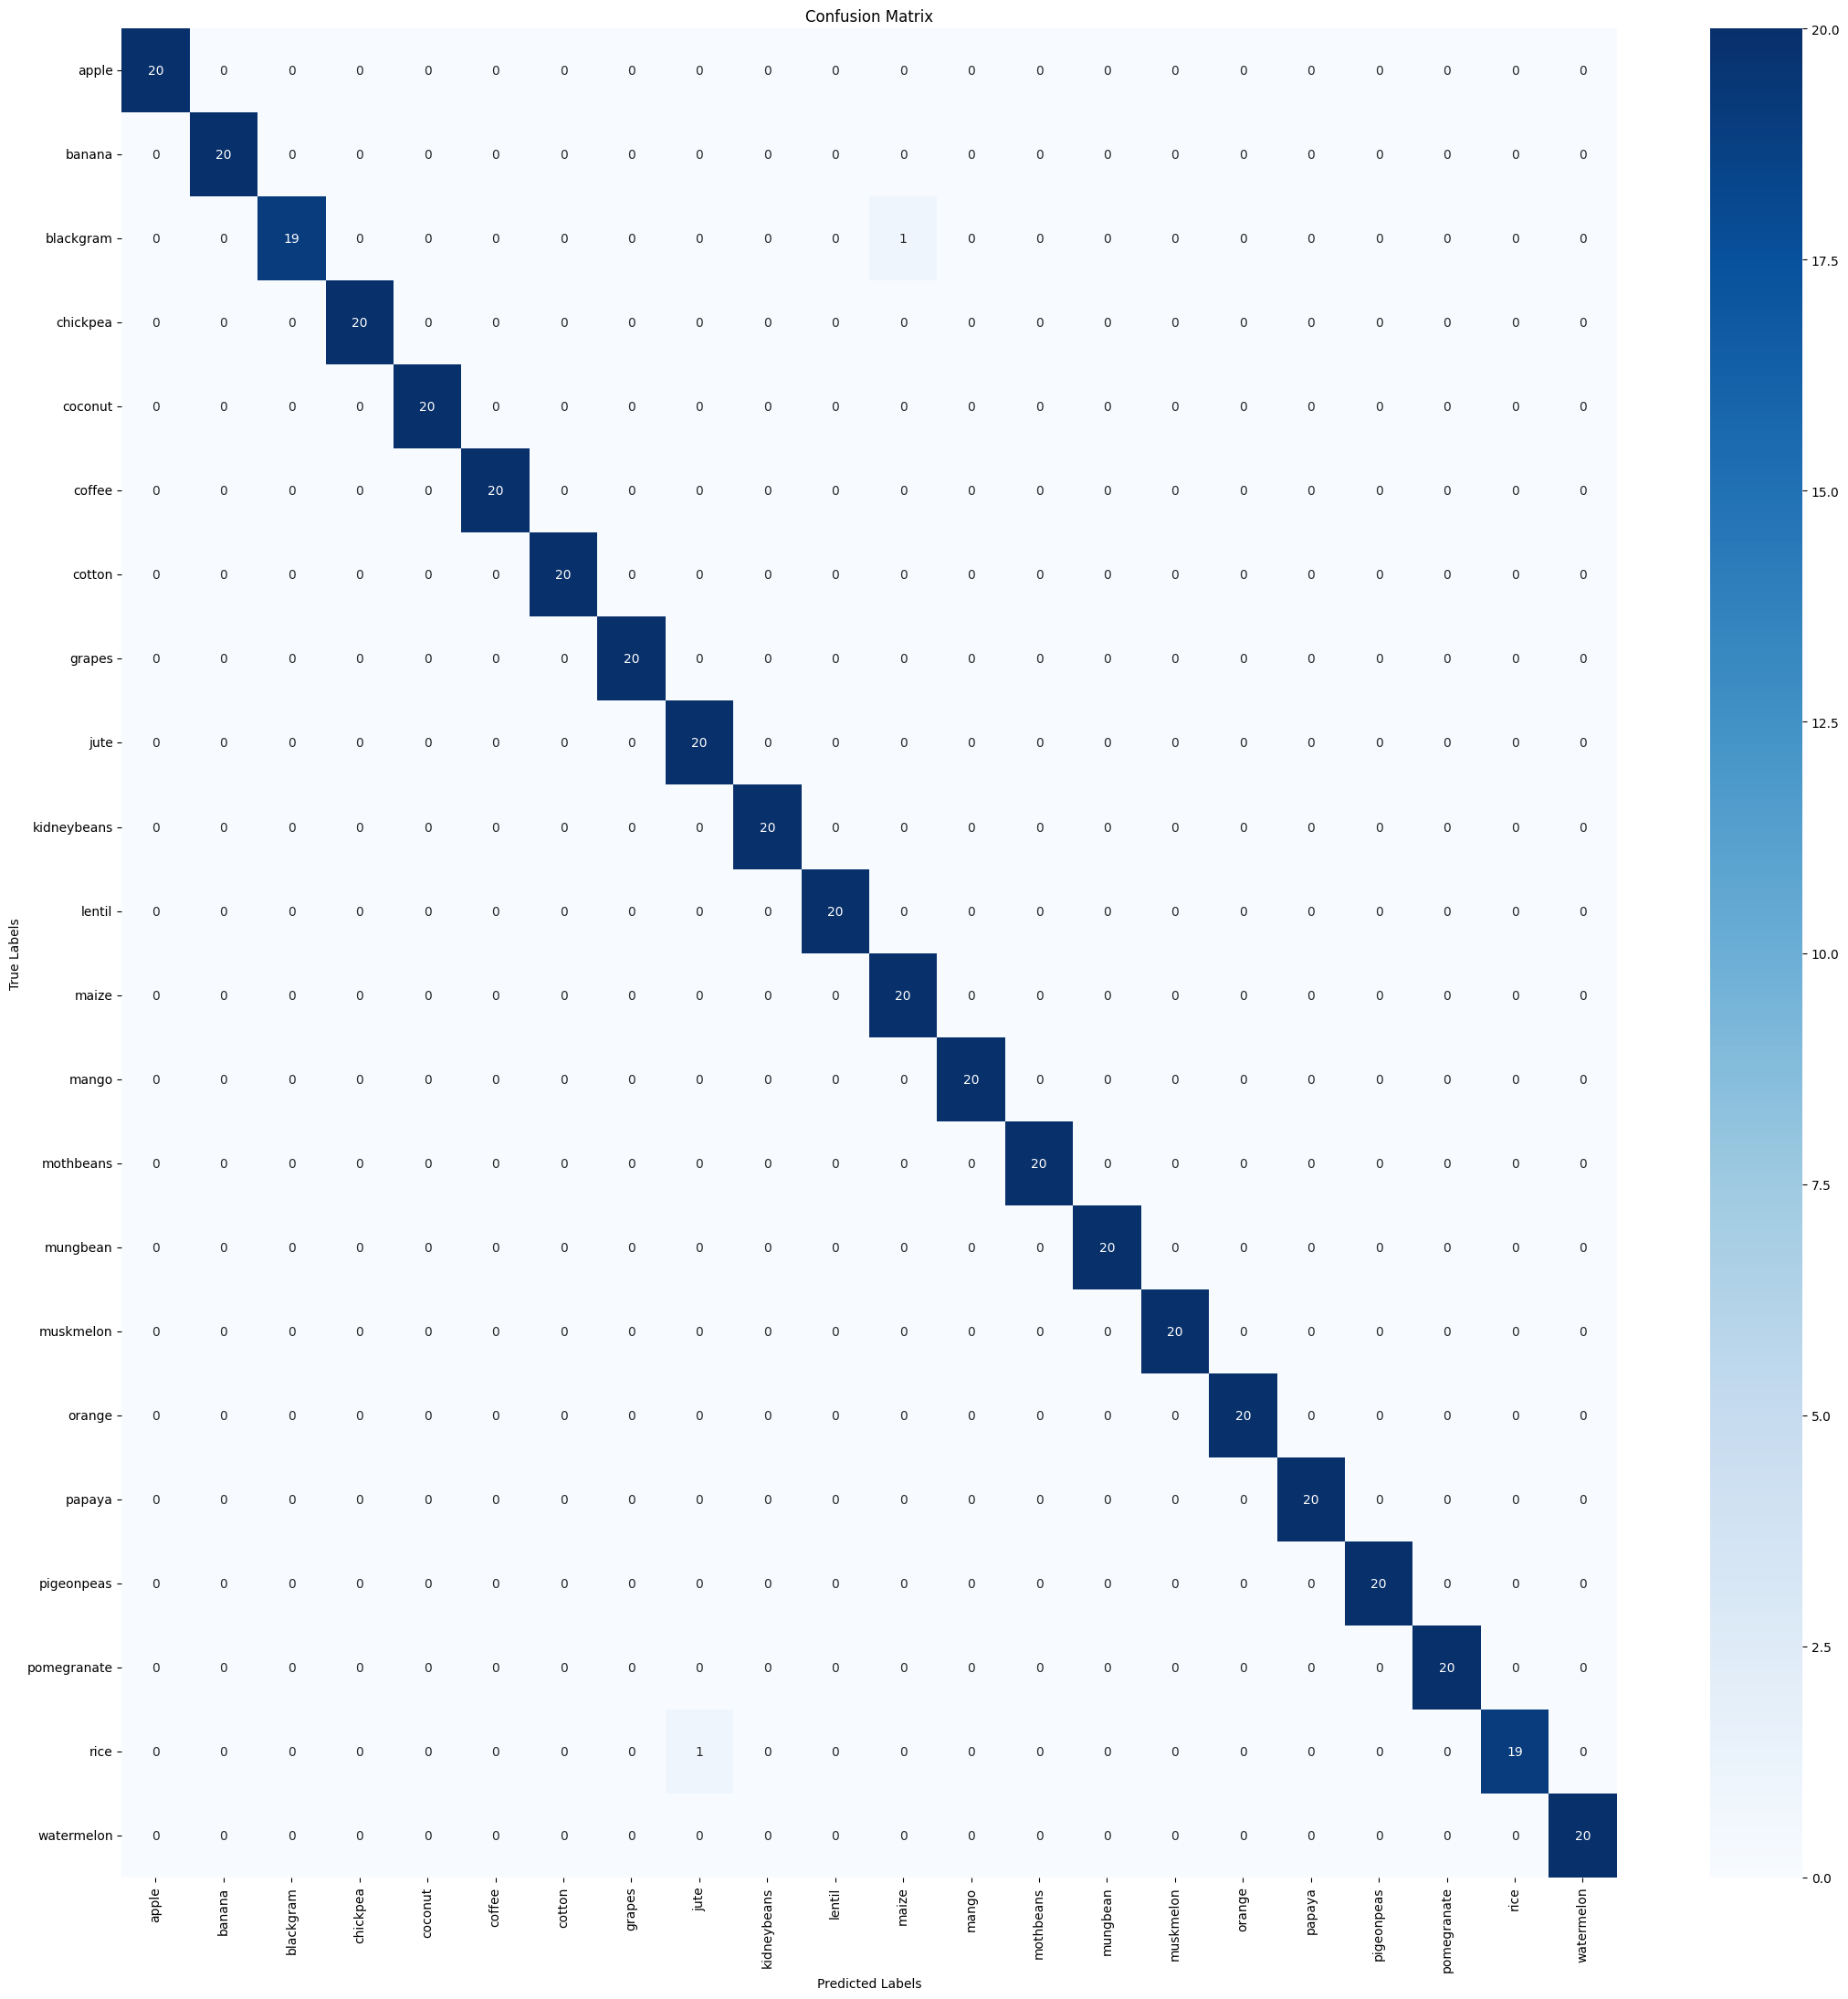

In [70]:
# 1. Confusion_Matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(Y_test,y_pred,labels=model.classes_)
plt.figure(figsize=(22,22))
sns.heatmap(cm,fmt="d",annot=True,cmap="Blues",xticklabels=model.classes_,yticklabels=model.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

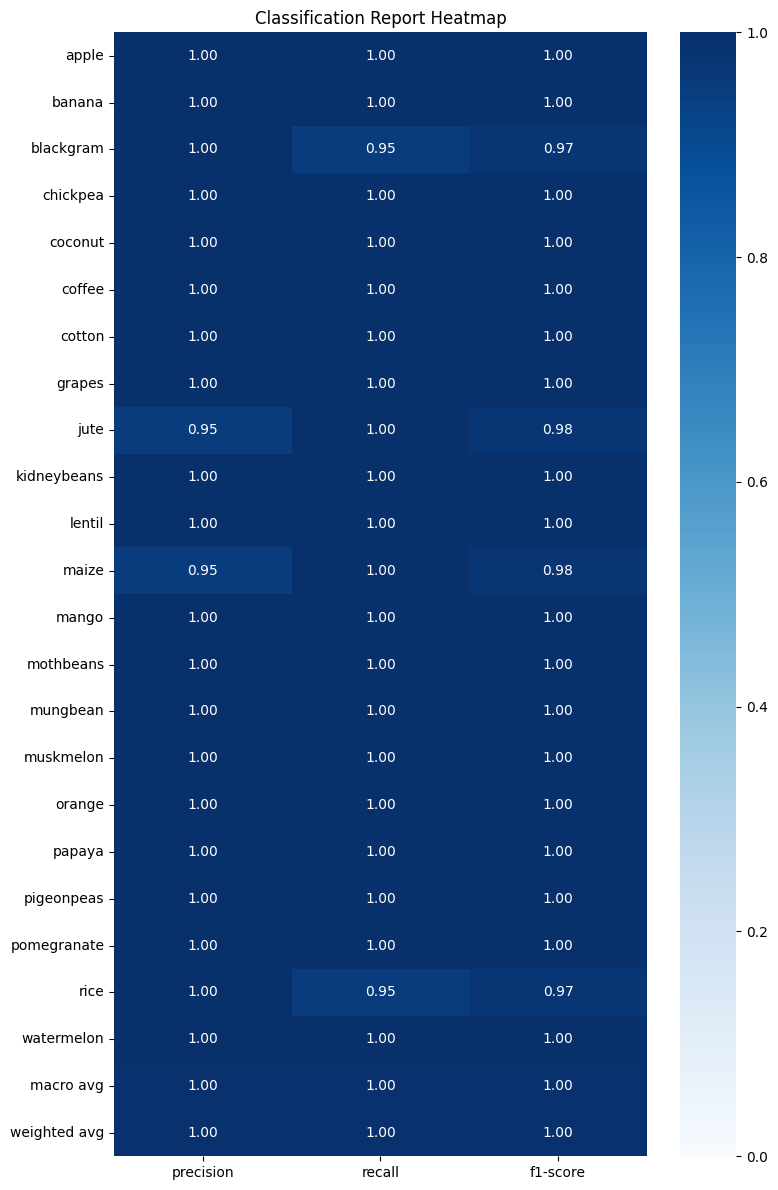

In [71]:
#2 Classification_report
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

report = classification_report(Y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# 'support' column aksar drop kar dete hain kyunki uska scale alag hota hai (counts vs 0-1 metrics)
report_df_plot = report_df.drop(columns=["support"])
# accuracy row bhi single scalar hoti hai, usse bhi hata sakte ho clean heatmap ke liye
report_df_plot = report_df_plot.drop(index=["accuracy"], errors="ignore")

plt.figure(figsize=(8,12))
sns.heatmap(report_df_plot, annot=True, cmap="Blues", fmt=".2f", vmin=0, vmax=1)
plt.title("Classification Report Heatmap")
plt.tight_layout()
plt.show()